# Quickstart

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/dev/overhaul/docs/get_started/quickstart.ipynb)

In January 1986, the Space Shuttle Challenger broke apart shortly after launch because an O-ring seal in one of its rocket boosters failed during unusually cold weather.
This notebook fits a Bayesian logistic regression of O-ring damage given the temperature at launch based on data from 23 earlier shuttle launches.
It then forecasts the probability of damage at the estimated temperature of 31°F near the rocket booster at the time of launch.
The notebook extends the example on the [home page](../index.md) into a short workflow:

1. **Specify** a model in terms of its prior and likelihood.
2. **Fit** the model with `condition_on`.
3. **Check** the fit with MCMC diagnostics and a posterior predictive check.
4. **Switch and compare** algorithms, by using the same model with other posterior inference algorithms.
5. **Forecast** using the posterior distribution.


## Setup

On Google Colab, the next cell installs ProbPipe and reads in the data from GitHub.
Otherwise, the notebook reads the copy of the data in the repository, and ProbPipe must already be installed, as [Installation](installation.md) describes.
The plots require matplotlib, which Colab includes.

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    data_path = "../tutorials/data/challenger.csv"
else:
    %pip install --quiet "probpipe-core @ git+https://github.com/TARPS-group/prob-pipe.git@dev/overhaul"
    data_path = "https://raw.githubusercontent.com/TARPS-group/prob-pipe/dev/overhaul/docs/tutorials/data/challenger.csv"

## The data

We first read in the data using pandas.
Each row of the data is a launch, with its flight number, the temperature at launch in °F, and a damage indicator that is 1 if an O-ring was damaged and 0 otherwise.

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from probpipe import (
    Normal, condition_on, function, mean,
    predictive_check, quantile, workflow_run,
)
from probpipe.diagnostics import add_mcmc_diagnostics
from probpipe.families import BernoulliFamily, glm_likelihood

data = pd.read_csv(data_path)
temperature = jnp.asarray(data["temperature"], dtype=jnp.float32)
damage = jnp.asarray(data["damage"], dtype=jnp.int32)

print("number of launches:", len(data))
print("launches with O-ring damage:", int(damage.sum()))
print("temperature of the coldest launch (°F):", int(data["temperature"].min()))

number of launches: 23
launches with O-ring damage: 7
temperature of the coldest launch (°F): 53


Here we plot the data. Notice the forecast temperature is far outside the range of the data, so predicting O-ring failure for the Challenger requires extrapolation. But, notably, all four launches below 65°F had damage.

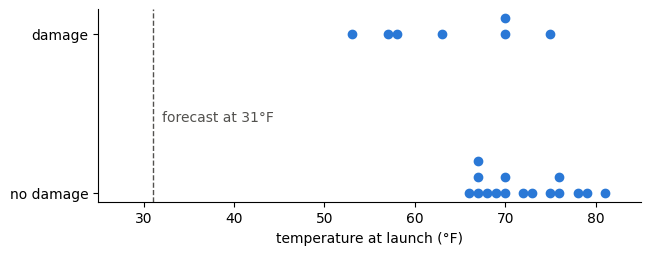

In [3]:
# Launches with the same temperature and outcome are stacked, so that each one shows.
stack = data.groupby(["temperature", "damage"]).cumcount()

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.scatter(data["temperature"], data["damage"] + 0.1 * stack, color="#2a78d6", zorder=2)
ax.axvline(31, color="#52514e", linestyle="--", linewidth=1)
ax.text(32, 0.45, "forecast at 31°F", color="#52514e")
ax.set_xlim(25, 85)
ax.set_yticks([0, 1], ["no damage", "damage"])
ax.set_xlabel("temperature at launch (°F)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 1. Specify the model

We will use a logistic regression model, which relates the log-odds of damage at launch $i$ to the temperature through an intercept and a slope:

$$\operatorname{logit} P(\text{damage}_i = 1) = \text{intercept} + \text{slope} \times \text{temperature}_i.$$

The intercept and the slope are the two coefficients $\beta = (\text{intercept}, \text{slope})$, and the model has three parts:

- **The prior** is a normal distribution of the two coefficients, with a scale of 10 for the intercept and 1 for the slope.
- **The likelihood** is a conditional distribution: given the coefficients, it is the distribution of the 23 damage indicators. `glm_likelihood` builds the likelihood as a generalized linear model: the Bernoulli family with its canonical logit link is logistic regression, and the design matrix `X` holds a column of ones, for the intercept, and the temperatures.
- **The model** composes the likelihood with the prior into the joint distribution of the coefficients and the data.

In [4]:
prior = Normal("beta", jnp.zeros(2), jnp.array([10.0, 1.0])).with_label("prior")

X = jnp.stack([jnp.ones_like(temperature), temperature], axis=1)
likelihood = glm_likelihood("damage", BernoulliFamily(), X=X).with_label("likelihood")

model = (likelihood * prior).with_label("oring_model")
print("model:", model)

model: FactoredDistribution(
    'oring_model',
    factors=(
        ConditionalDistribution(
            'likelihood',
            family=BernoulliFamily(),
            link=Function('logit', parameters=('mean',)),
            X=array(shape=(23, 2), dtype=float32),
            given=('beta',),
            event_spec=OutputSpec(damage=NumericArraySpec(shape=(23,), support=boolean)),
        ),
        Normal(
            'prior',
            loc=[0.0, 0.0],
            scale=[10.0, 1.0],
            event_spec=OutputSpec(beta=NumericArraySpec(shape=(2,), dtype=float32, support=real)),
        ),
    ),
)


## 2. Fit the model

`condition_on(model, observed)` fixes the damage indicators at their observed values and returns the posterior distribution of the intercept and the slope.
ProbPipe selects how to compute it, and `condition_on.check` reports the selection without running it:

In [5]:
observed = {"damage": damage}
report = condition_on.check(model, observed)
print("selected route and method:", report.selected.method_name)

selected route and method: inference_methods/blackjax_nuts


No exact method applies to this model, since the posterior of a logistic regression has no closed form.
`condition_on` therefore takes the route `inference_methods`, which forms the unnormalized posterior and passes it to an inference method.
The inference method `blackjax_nuts` then draws from the posterior with BlackJAX's No-U-Turn Sampler (NUTS).
In a notebook, displaying `report` shows a table of every route that `condition_on` evaluated, with the reason each other route declined.

The fit runs inside `workflow_run(seed=0)`, which seeds the random draws of the block, so rerunning the cell reproduces the posterior.

In [6]:
with workflow_run(seed=0):
    posterior = condition_on(model, observed)

print("posterior:", posterior)
print("method that produced the posterior:", posterior.provenance.metadata["method"])
intercept_mean, slope_mean = mean(posterior["beta"]).raw()
print("posterior mean of the intercept:", round(float(intercept_mean), 2))
print("posterior mean of the slope:", round(float(slope_mean), 3))

posterior: EmpiricalDistribution(
    'oring_model | damage',
    atoms=NumericRecordBatch('posterior', levels={'chain': 4, 'draw': 1000}, fields=('beta',)),
)
method that produced the posterior: blackjax_nuts
posterior mean of the intercept: 11.6
posterior mean of the slope: -0.183


The posterior is an `EmpiricalDistribution` of 4 chains of 1,000 draws each.
Its provenance records the operation that produced it, and the provenance's `metadata` provides the route and the method.
The slope's posterior mean of −0.18 indicates that each degree colder raises the log-odds of damage by about 0.18.

## 3. Check the fit

### MCMC diagnostics

NUTS returns correlated draws from four chains, so we use two diagnostics to evaluate accuracy:

- **R-hat** compares the variability within each chain with the variability between the chains. Values below 1.01 indicate that the chains agree.
- **Effective sample size (ESS)** is the number of independent draws that the correlated draws are equivalent to when used to estimate the mean of the distribution (bulk) and its tails (tail).

`add_mcmc_diagnostics` computes both and records them on the posterior, and `posterior.diagnostics` reads them:

In [7]:
add_mcmc_diagnostics(posterior)
print(posterior.diagnostics.summary_table())

Parameter     R-hat     ESS bulk    ESS tail    MCSE mean   
------------------------------------------------------------
beta[0]       1.0086    499.7359    556.7652    0.2418      
beta[1]       1.0085    499.3875    559.3519    0.0036      

✓  All available diagnostics passed.


R-hat is below 1.01 for both parameters, and each effective sample size exceeds the threshold of 400 below which `add_mcmc_diagnostics` provides a warning.
`posterior.annotations["arviz"]` holds the draws as ArviZ data, with one variable, `beta`, whose two entries are the intercept and the slope, so ArviZ's summaries and plots also apply to them.

### The posterior draws

ArviZ's plots apply to the posterior's ArviZ data.
A pair plot shows the joint posterior of the intercept and the slope, and an autocorrelation plot shows how strongly each chain's successive draws depend on one another.

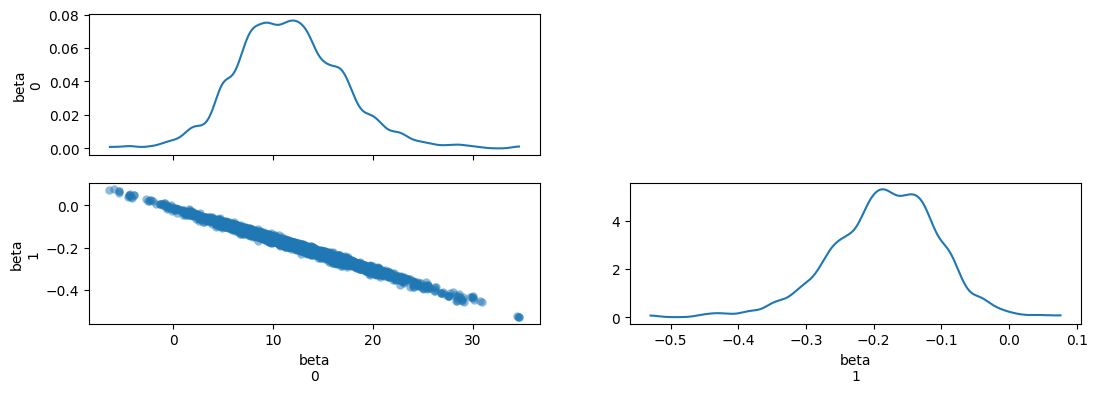

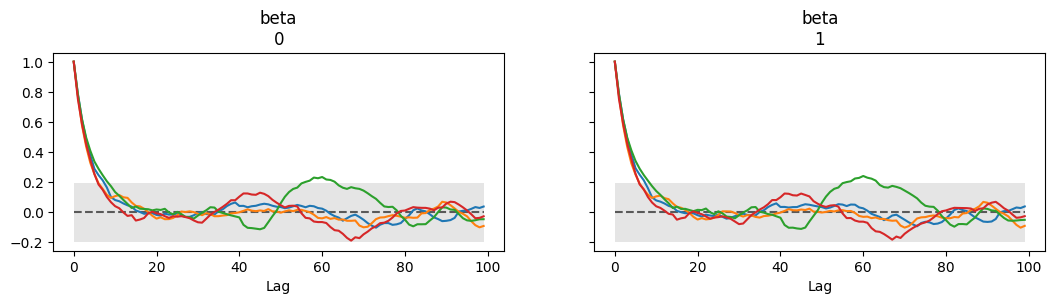

In [8]:
import arviz as az

arviz_data = posterior.annotations["arviz"]
az.plot_pair(arviz_data)
plt.show()
az.plot_autocorr(arviz_data)
plt.show()

The draws lie along a narrow ridge, with a posterior correlation near −1:
a larger intercept fits the data as well as a smaller one does when the slope decreases to offset it.
The sampler must move along the ridge in short steps, so each chain's successive draws are correlated.
The autocorrelation falls below 0.1 only after about 10 draws.
For that reason the 4,000 draws are equivalent to about 500 independent ones (the effective sample size).

### Posterior predictive check

A posterior predictive check simulates replicated data from the fitted model and compares them with the observed data through test statistics.
Each replication draws an intercept and a slope from the posterior, and then 23 damage indicators from the likelihood at those values.
`predictive_check` takes the likelihood, the posterior over the likelihood's given values, the statistics, and the observed data.
Two statistics suit binary data like these:

- `damaged_launches`: the number of launches with damage;
- `damaged_cold_launches`: the number of damaged launches among the four below 65°F, which tests the model at the cold end of the data, where it is nearest the forecast temperature.

In [9]:
cold = temperature < 65


def damaged_launches(damage: jax.Array) -> jax.Array:
    return jnp.sum(damage)


def damaged_cold_launches(damage: jax.Array) -> jax.Array:
    return jnp.sum(jnp.where(cold, damage, 0))


with workflow_run(seed=1):
    check = predictive_check(
        likelihood, posterior, [damaged_launches, damaged_cold_launches], observed
    )

statistics = ["damaged_launches", "damaged_cold_launches"]
pd.DataFrame(
    {
        name: {
            "observed": float(check[f"{name}/observed_statistic"]),
            "mean of the replications": float(mean(check[f"{name}/replicated_statistics"])),
            "p-value": float(check[f"{name}/p_value"]),
        }
        for name in statistics
    }
).T

,observed,mean of the replications,p-value
damaged_launches,7.0,7.032001,0.552
damaged_cold_launches,4.0,2.832000,0.284


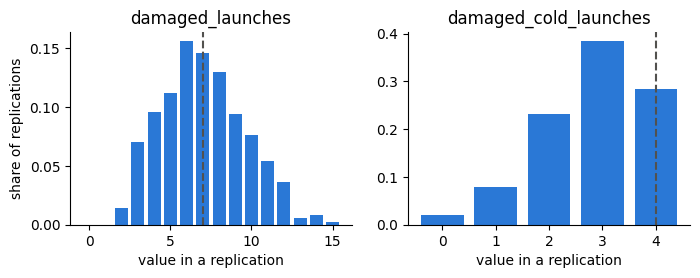

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 2.5))
for ax, name in zip(axes, statistics):
    replications = np.asarray(check[f"{name}/replicated_statistics"].atoms).astype(int)
    counts = np.bincount(replications)
    ax.bar(range(len(counts)), counts / len(replications), color="#2a78d6")
    ax.axvline(float(check[f"{name}/observed_statistic"]), color="#52514e", linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("value in a replication")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("share of replications")
plt.show()

The bars show the distribution of each statistic over 500 replications, and the dashed line marks its observed value.
A p-value is the share of replications whose statistic is at least the observed one, so a p-value near 0 or 1 signals that the model misses that feature of the data.
The p-values are 0.55 for `damaged_launches` and 0.28 for `damaged_cold_launches`, so neither statistic provides evidence of misfit.

## 4. Switch and compare algorithms

By calling `condition_on.with_options(method=method)(...)`, we can invoke an applicable algorithm `method` to compute the posterior.
By looping through a list of method names, we can easily compare many different posterior inference algorithms.

In [11]:
import warnings

comparison = {}
for method in ["blackjax_nuts", "tfp_nuts", "blackjax_rwmh"]:
    with workflow_run(seed=0):
        fit = condition_on.with_options(method=method)(model, observed)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # the table shows what the diagnostics would warn about
        add_mcmc_diagnostics(fit)
    intercept_mean, slope_mean = mean(fit["beta"]).raw()
    comparison[method] = {
        "mean of the intercept": float(intercept_mean),
        "mean of the slope": float(slope_mean),
        "largest R-hat": max(fit.diagnostics.mcmc.rhat.values()),
        "smallest bulk ESS": min(fit.diagnostics.mcmc.ess_bulk.values()),
    }
pd.DataFrame(comparison).T.round(3)

,mean of the intercept,mean of the slope,largest R-hat,smallest bulk ESS
blackjax_nuts,11.602,-0.183,1.009,499.387
tfp_nuts,11.822,-0.186,1.003,458.220
blackjax_rwmh,4.719,-0.083,1.973,5.483


BlackJAX and TensorFlow Probability's implementations of NUTS agree to within their Monte Carlo error, and both pass their diagnostics.
Random-walk Metropolis, on the other hand, has posterior mean estimates that are far from the others.
Its unreliability is supported by a largest R-hat value of nearly 2 and an effective sample size of less than 6.

## 5. Forecast

The probability of damage at a temperature $t$ is the logistic function of $\text{intercept} + \text{slope} \times t$.
The `challenger_damage_probability` function computes that value at $t =$ 31°F for one pair of coefficients. The `@function` decorator makes it into a ProbPipe-native function.

In [12]:
@function
def challenger_damage_probability(beta: jax.Array) -> jax.Array:
    return jax.nn.sigmoid(beta[0] + beta[1] * 31.0)


with workflow_run(seed=2):
    damage_prob = challenger_damage_probability(posterior["beta"])

print("number of draws used to forecast:", damage_prob.num_atoms)
print("P(damage at 31°F), posterior mean:", round(float(mean(damage_prob)), 3))
print("P(damage at 31°F), 90% interval:", quantile(damage_prob, jnp.array([0.05, 0.95])).raw())

number of draws used to forecast: 256
P(damage at 31°F), posterior mean: 0.964


P(damage at 31°F), 90% interval: [0.8174724  0.99998176]


Although we only had to define `challenger_damage_probability` for a single pair of coefficients, here it receives the posterior's field `beta`, which is a distribution.
ProbPipe therefore *lifts* the function: it evaluates the function at 256 draws from the posterior, and it returns the distribution of the results.
Using `challenger_damage_probability.with_options(n_broadcast_samples=1000)(...)` would evaluate the function at 1,000 draws instead.

The posterior mean of the probability of damage at 31°F is 0.96, and its 90% interval runs from 0.82 to almost 1.
The forecast extrapolates 22°F below the coldest launch in the data, so it depends on the logistic form of the model as well as on the data.

## Next steps

- [Installation](https://tarps-group.github.io/prob-pipe/get_started/installation/) provides guidance for installing ProbPipe locally or with extras such as Stan and PyMC.
- [The tutorials](https://tarps-group.github.io/prob-pipe/tutorials/01_first_analysis/) work through a complete statistical analysis of a moose population, including model checks, model elaboration, forecasting, and fitting models with likelihood-free methods.
- [The API reference](https://tarps-group.github.io/prob-pipe/api/) provides complete documentation of ProbPipe capabilities.

> **Human-validated** by Jonathan Huggins on 2026-10-04.